---
title: State-space construction
---

In [1]:
from phasic import Graph
import sys
import numpy as np
import seaborn as sns
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')


Manual construction using the python low level API:

In [2]:
def coalescent(nr_samples):

    # we represent the state as a vector of integers, the numbers of lineages 
    # with "index" number of descendants
    state_vector_length = nr_samples

    # make an empty graph specifying the length of its state vectors
    graph = Graph(state_vector_length)

    # create the initial state where all samples are singletons
    initial_state = np.zeros(state_vector_length, dtype=int)
    initial_state[0] = nr_samples

    # find the initial state or create it if it does not exist yet
    vertex = graph.find_or_create_vertex(initial_state)

    # add an edge from the starting vertex to the initial state
    # signifying that the Markov chain starts in that state with 
    # probability 1
    graph.starting_vertex().add_edge(vertex, 1)

    # Graph index of the current vertex to process: The starting 
    # vertex is at index 0, so the initial_state is at index 1
    index = 1

    # For each vertex visited, we may create new child vertices not
    # yet visited. The while loop makes sure we continue processing
    # states until we have visited the ones we have created:
    while index < graph.vertices_length():

        # get the vertex at the current index
        vertex = graph.vertex_at(index)
        # get the state vector of that vertex
        state = vertex.state()

        # iterate over all combinations of the kinds of lineages
        # (singleton, doubleton, etc):
        for i in range(nr_samples):
            for j in range(i, nr_samples): 

                # if the two kinds are the same, there need to be at
                # least two lineages of that kind to coalesce
                same = int(i == j)
                if same and state[i] < 2:
                    continue

                # otherwise, at least one of each kind
                if not same and (state[i] < 1 or state[j] < 1):
                    continue 

                # create the new state vector to represent the child
                # state produced by the coalescence event
                new_state = state.copy()
                new_state[i] -= 1
                new_state[j] -= 1
                new_state[i+j+1] += 1
                
                # find the vertex with this state if it exists or 
                # create it otherwise
                new_vertex = graph.find_or_create_vertex(new_state)

                # compute the coalescent rate
                rate = state[i]*(state[j]-same)/(1+same)

                # add an edge from the current vertex to the new 
                # vertex and make its weight the coalescent rate
                vertex.add_edge(new_vertex, rate)

        # increment the index to process the next graph vertex
        index += 1
    
    return graph

Or just:

In [3]:
def coalescent(nr_samples):
    state_vector_length = nr_samples
    graph = Graph(state_vector_length)
    initial_state = np.zeros(state_vector_length, dtype=int)
    initial_state[0] = nr_samples
    vertex = graph.find_or_create_vertex(initial_state)
    graph.starting_vertex().add_edge(vertex, 1)
    index = 1
    while index < graph.vertices_length():
        vertex = graph.vertex_at(index)
        state = vertex.state()
        for i in range(nr_samples):
            for j in range(i, nr_samples): 
                same = int(i == j)
                if same and state[i] < 2:
                    continue
                if not same and (state[i] < 1 or state[j] < 1):
                    continue 
                new_state = state.copy()
                new_state[i] -= 1
                new_state[j] -= 1
                new_state[i+j+1] += 1
                new_vertex = graph.find_or_create_vertex(new_state)
                rate = state[i]*(state[j]-same)/(1+same)
                vertex.add_edge(new_vertex, rate)
        index += 1
    return graph

In [4]:
graph = coalescent(4)
graph.vertices_length()

6

You can access state vectors as a two-dimensional array:

In [5]:
graph.states()

array([[0, 0, 0, 0],
       [4, 0, 0, 0],
       [2, 1, 0, 0],
       [0, 2, 0, 0],
       [1, 0, 1, 0],
       [0, 0, 0, 1]], dtype=int32)

and you can plot the graph for visual inspection. See the next tutorial on [visualizing graphs](./visualize.ipynb) for more details.

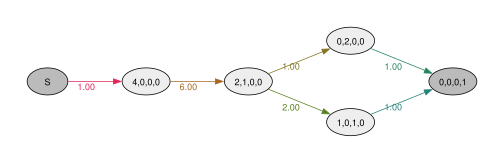

In [6]:
#| label: fig-coalescent-graph
#| fig-cap: "State space graph."

graph.plot()

::: { .callout-tip }

## Vertex and Edge APIs

Vertices and Edges each have additional methods for advanced construction and manipulation of graphs not needed for normal use. To learn more, see the [API documentation](../../api/index.qmd).

:::

## Easy graph build with callback function

You can skip the boilerplate code by passing a callback function and initial state probabilities to `Graph`. The callback function must accept a list/array of integers specifying a state and it must return a list of lists, each list with two elements: a state (list of integers) and a rate (float). It will often look something like this:

In [7]:
def mygraph(state):
    transitions = []
    for i in state:
        child_state = ...
        rate = ...
        transitions.append([child_state, rate])
    return transitions

To create a callback function, just think of rules of your model and ask yourself: "Given some state, what are the allowed transitions to other states and with what rates to these transitions occur?". If the current state is "two singletons and one doubleton" (`[2, 1, 0, 0]`), the process can jump to "one singleton and one tripleton" (`[1, 0, 1, 0]`) with rate 2 and to "two doubletons" (`[0, 2, 0, 0]`) with rate 1. Here is a callback function building a graph for the coalescent in the say way as in our first example:

In [8]:
#| label: fig-coalescent-callback
#| fig-cap: "Graph defined using a callback function."

def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

Along with the callback function, you must pass the `ipv`, a list of lists, each with a state and its initial probability. All additional keyword arguments are passed to `Graph` are passed on to your callback function.

In [9]:
nr_samples = 4
ipv = [([nr_samples]+[0]*(nr_samples-1), 1)]
graph = Graph(coalescent, ipv=ipv)

If the ipv only has a single state `Graph` also accepts just the single state without the rate of 1:

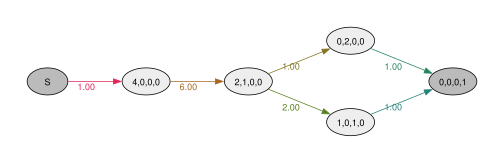

In [10]:
#| label: fig-coalescent-callback-simpleipv
#| fig-cap: "Using simple list for initial state."


nr_samples = 4
ipv = [nr_samples]+[0]*(nr_samples-1)
graph = Graph(coalescent, ipv=ipv)
graph.plot()

Your callback is wrapped in decorator that makes your function return the ipv if an empty state vector is passed, does various type checks, and formats your return value. To expose this for testing, debugging, or convenience, you can decorate your callback yourself (in which case phasic will know and not do it again):

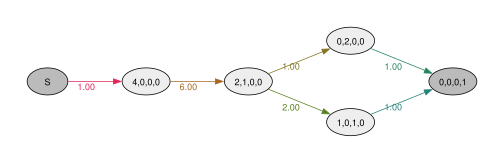

In [11]:
#| label: fig-coalescent-callback-decorated
#| fig-cap: "Using decorated callback."


from phasic import with_ipv

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

graph = Graph(coalescent)
graph.plot()

## Matrix interface

To allow imbedding in a matrix based workflow, a matrix-based representation of the phase-type distribution can be extracted from the graph. Note that the indices in the matrix representation do not correspond to vertex indices in the graph.

In [12]:
mats = graph.as_matrices()
print("Initial probability vector:")
print(mats.ipv)
print("Subintensity matrix:")
print(mats.sim)
print("States:")
print(mats.states)
print("Indicies:")
print(mats.indices)


Initial probability vector:
[1. 0. 0. 0.]
Subintensity matrix:
[[-6.  6.  0.  0.]
 [ 0. -3.  1.  2.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]
States:
[[4 0 0 0]
 [2 1 0 0]
 [0 2 0 0]
 [1 0 1 0]]
Indicies:
[2 3 4 5]


Although computationally inefficient, the graph can also be constructed from an initial probability vector and a subintensity matrix:

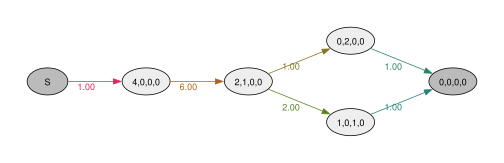

In [13]:
#| label: fig-coalescent-from-matrices
#| fig-cap: "Generated from matrices and state vectors."

graph = Graph.from_matrices(mats.ipv, mats.sim, mats.states)
graph.plot()

If the state argument is not provided, matrix indices are used as matrix states:

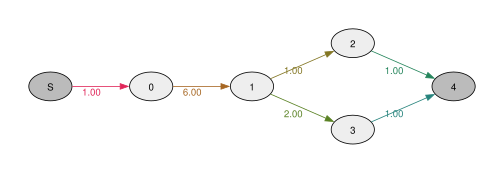

In [14]:
#| label: fig-coalescent-from-matrices-default
#| fig-cap: "Generated from only matrices."


graph = Graph.from_matrices(mats.ipv, mats.sim)
graph.plot()

## Graph caching

When building graphs using callback functions, the graph cache (``~/.phasic_cache/graphs/``) allows fast reconstruction of graphs that take a long time to build. This especially true for models (like the coalescent) where each visited vertex requires  nested for loops over the state vector. 

The cache key is a SHA-256 hash of callback function's AST (so whitespace/comment changes are ignored) and all other parameters passed to it including the IPV. So any change to the callback code or parameters will invalidate the cache.

In [15]:
from phasic import (
    Graph, with_ipv, GraphCache,
    print_graph_cache_info, get_graph_cache_stats
)
import numpy as np
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')

In [16]:
#| echo: false
#| output: false
cache = GraphCache()
cache.clear()

2

In [17]:
def coalescent(state, N=None):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same) / N ))
    return transitions

nr_samples = 40
initial = [([nr_samples]+[0]*(nr_samples-1), 1)]

With $|V|$ vertices and a state vector length of $s$, building this graph is $O(|V| s^2)$.

In [18]:
%%time
graph = Graph(coalescent, ipv=initial, N=10000, graph_cache=True)

CPU times: user 10.3 s, sys: 371 ms, total: 10.6 s
Wall time: 10.9 s


Reconstructing it from cache is only  $O(|V|)$.

In [19]:
%%time
graph = Graph(coalescent, ipv=initial, N=10000, graph_cache=True)

CPU times: user 1.81 s, sys: 63.5 ms, total: 1.87 s
Wall time: 1.88 s


If `graph_cache=True` is not passed, the graph is built from scratch:

In [20]:
%%time
graph = Graph(coalescent, ipv=initial, N=10000)

CPU times: user 7.07 s, sys: 58.1 ms, total: 7.13 s
Wall time: 7.14 s




### Cache Inspection



In [21]:
print_graph_cache_info()

Cache directory: /Users/kmt/.phasic_cache/graphs
Cached graphs: 1
Total size: 50.93 MB


In [22]:
get_graph_cache_stats()


{'num_graphs': 1,
 'total_size_mb': 50.92805290222168,
 'cache_dir': '/Users/kmt/.phasic_cache/graphs'}

### Custom Class Serialization

`StateIndexer` supports serialization, but if you want to pass own objects as parameters to the constructor callback, make sure it implements `to_dict()` and `from_dict()` and that its `__repr__` is deterministic like in the example below:

In [23]:
class MyModel:
    def __init__(self, param1, param2):
        self.param1 = param1
        self.param2 = param2

    def to_dict(self):
        return {'param1': self.param1, 'param2': self.param2}
    
    @classmethod
    def from_dict(cls, data):
        return cls(data['param1'], data['param2'])

    def __repr__(self):
        return repr({'param1': self.param1, 'param2': self.param2})


@with_ipv(ipv=[1])
def callback(state, model):
    transitions = []
    if state[0] == 1:
        transitions.append([[2], [model.param1, model.param2]])
    return transitions

# Now cacheable!
model = MyModel(1.0, 2.0)
graph = Graph(callback, model=model, graph_cache=True)

## Building the state space in C

Some models very large models can be take a long time to construct. To speed this up you implement the model construction using the C or C++ API and import it as a python module. This requires the `cppimport` available as conda and pypi package. Here is a function building the coalescent using the C++ API:

```cpp
phasic::Graph build(int nr_samples) {
  phasic::Graph graph(nr_samples);
  std::vector<int> initial_state(graph.state_length(), 0);
  initial_state[0] = nr_samples;
  phasic::Vertex start = graph.starting_vertex();
  phasic::Vertex initial = graph.find_or_create_vertex(initial_state);
  start.add_edge(initial, 1.0);
  for (size_t k = 1; k < graph.vertices_length(); k++) {
    phasic::Vertex vertex = graph.vertex_at(k);
    for (int i = 0; i < nr_samples; ++i) {
      for (int j = i; j < nr_samples && i + j + 1 < nr_samples; ++j) {
        bool same = (i == j);
        std::vector<int> state = vertex.state();
        if (same && state[i] < 2) {
          continue;
        }
        if (!same && (state[i] < 1 || state[j] < 1)) {
          continue;
        }
        state[i]--;
        state[j]--;
        state[i + j + 1]++;
        double weight = same ? (state[i] + 1) * (state[i] + 2) / 2.0
                              : (state[i] + 1) * (state[j] + 1);
        phasic::Vertex child = graph.find_or_create_vertex(state);
        vertex.add_edge(child, weight);
      }
    }
  }
  return graph;
}
```

Wrap it in the header and footer shown below and save it to a cpp file named after as your module:

```cpp
// cppimport
#include <pybind11/pybind11.h>
#include <phasiccpp.h>

#include <vector>

namespace py = pybind11;

using namespace pybind11::literals;

/* ----------------- Don't change the code above! ----------------- */
/* -----------------------------------------------------------------*/

phasic::Graph build(int nr_samples) {
  phasic::Graph graph(nr_samples);
  std::vector<int> initial_state(graph.state_length(), 0);
  initial_state[0] = nr_samples;
  phasic::Vertex start = graph.starting_vertex();
  phasic::Vertex initial = graph.find_or_create_vertex(initial_state);
  start.add_edge(initial, 1.0);
  for (size_t k = 1; k < graph.vertices_length(); k++) {
    phasic::Vertex vertex = graph.vertex_at(k);
    for (int i = 0; i < nr_samples; ++i) {
      for (int j = i; j < nr_samples && i + j + 1 < nr_samples; ++j) {
        bool same = (i == j);
        std::vector<int> state = vertex.state();
        if (same && state[i] < 2) {
          continue;
        }
        if (!same && (state[i] < 1 || state[j] < 1)) {
          continue;
        }
        state[i]--;
        state[j]--;
        state[i + j + 1]++;
        double weight = same ? (state[i] + 1) * (state[i] + 2) / 2.0
                              : (state[i] + 1) * (state[j] + 1);
        phasic::Vertex child = graph.find_or_create_vertex(state);
        vertex.add_edge(child, weight);
      }
    }
  }
  return graph;
}


PYBIND11_MODULE(coalescent_state_space, m) { /* NB: module name must match file base name */

        m.def("build", &build); /* NB: must match name of function defined above */
}
/* -----------------------------------------------------------------*/
/* --------------- Don't change the content below! ---------------- */


/*
<%
import os, sys, phasic
phasic_dir = os.path.dirname(phasic.__file__)
cfg["include_dirs"] += [
    os.path.join(phasic_dir, "include", "c"),
    os.path.join(phasic_dir, "include", "cpp"),
]
# Compile the C++ wrapper implementation alongside this module. The C++
# methods (Graph::starting_vertex, Graph::find_or_create_vertex, etc.)
# are defined out-of-line in phasiccpp.cpp; the phasic_pybind extension
# does not re-export C++ symbols, so we build our own copy here. The
# methods themselves just call into the ptd_* C API, which IS exported
# from phasic_pybind.so.
cfg["sources"] += [os.path.join(phasic_dir, "include", "cpp", "phasiccpp.cpp")]

# Resolve ptd_* symbols at runtime from whatever's already loaded in the
# Python process. The phasic Python package loads phasic_pybind.so into
# the interpreter, which exports the ptd_* C symbols. Dynamic-lookup
# defers resolution to module-load time. On Linux this is the default
# behaviour; on macOS we have to ask for it; on Windows we'd need to
# link against an import library.
if sys.platform == "darwin":
    cfg["extra_link_args"] += ["-Wl,-undefined,dynamic_lookup"]
elif sys.platform == "win32":
    raise RuntimeError(
        "Windows cppimport linkage is not supported in this tutorial. "
        "Build phasic from source or use the Python API directly."
    )
setup_pybind11(cfg)
%>
*/
```

You can see the complete code in [cpp_state_spaces.cpp](cpp_state_spaces.cpp).

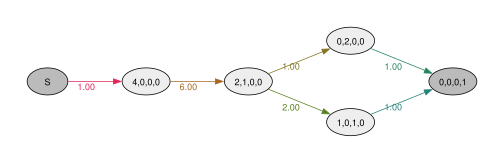

In [25]:
import cppimport.import_hook
import cpp_state_spaces # import your extension

graph = Graph(cpp_state_spaces.coalescent(4)) # wrap the returned pybind11 object in Graph
graph.plot()

### Speed comparison

The CPP version usually builds at least ten times faster:

In [25]:
nr_samples = 40
initial = [([nr_samples]+[0]*(nr_samples-1), 1)]

def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

In [51]:
%%timeit
graph = Graph(coalescent, ipv=initial)

7.08 s ± 47.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [52]:
%%timeit
graph = Graph(cpp_state_spaces.coalescent(nr_samples))

577 ms ± 23.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
